# End-to-End Heart Disease Diagnostic System

## Project Setup and Data Loading

In [1]:
# Mini-Project: End-to-End Heart Disease Diagnostic System
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# 1. Load the cleaned data (from Practical 1)
df = pd.read_csv('../data/heart_clean.csv')

# 2. Define Features (X) and Target (y)
X = df.drop(columns=['num', 'id', 'dataset'], errors='ignore')
X = pd.get_dummies(X, drop_first=True) # Handle categorical text
y = (df['num'] > 0).astype(int)        # Binary target: 0 (Healthy), 1 (Disease)

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Project Setup Complete! Data is ready for the models.")

Project Setup Complete! Data is ready for the models.


## Train and Compare Multiple Models

--- Baseline Model Accuracies ---
Logistic Regression       : 80.43%
k-Nearest Neighbors       : 80.98%
Multilayer Perceptron     : 80.98%


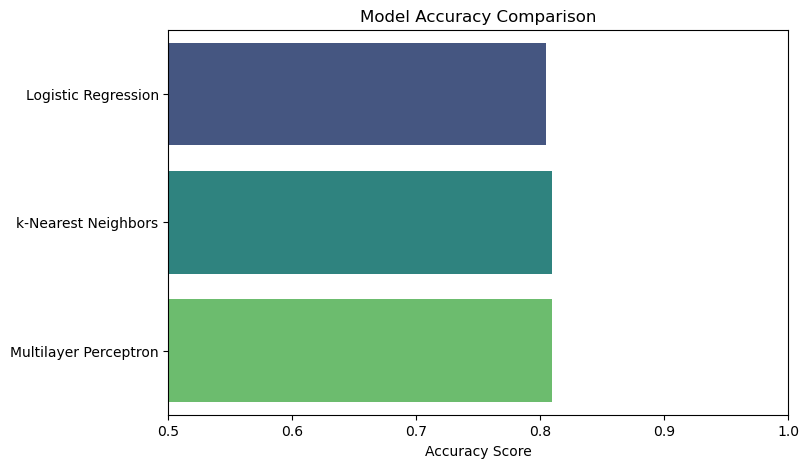

In [5]:
# Initialize the three models we learned in the lab
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Multilayer Perceptron": MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1500, random_state=42)
}

# Dictionary to store the accuracy of each model
results = {}

print("--- Baseline Model Accuracies ---")
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    y_pred = model.predict(X_test_scaled)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} : {acc * 100:.2f}%")

# Visualize the comparison
plt.figure(figsize=(8, 5))

# Extract keys and values to variables for cleaner code
model_names = list(results.keys())
model_scores = list(results.values())

# FIX: Added 'hue' and 'legend=False' to comply with the latest seaborn updates!
sns.barplot(
    x=model_scores, 
    y=model_names, 
    hue=model_names, 
    palette='viridis', 
    legend=False
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy Score')
plt.xlim(0.5, 1.0) # Zoom in to see the differences clearly
plt.show()

## Advanced Evaluation - The ROC Curve

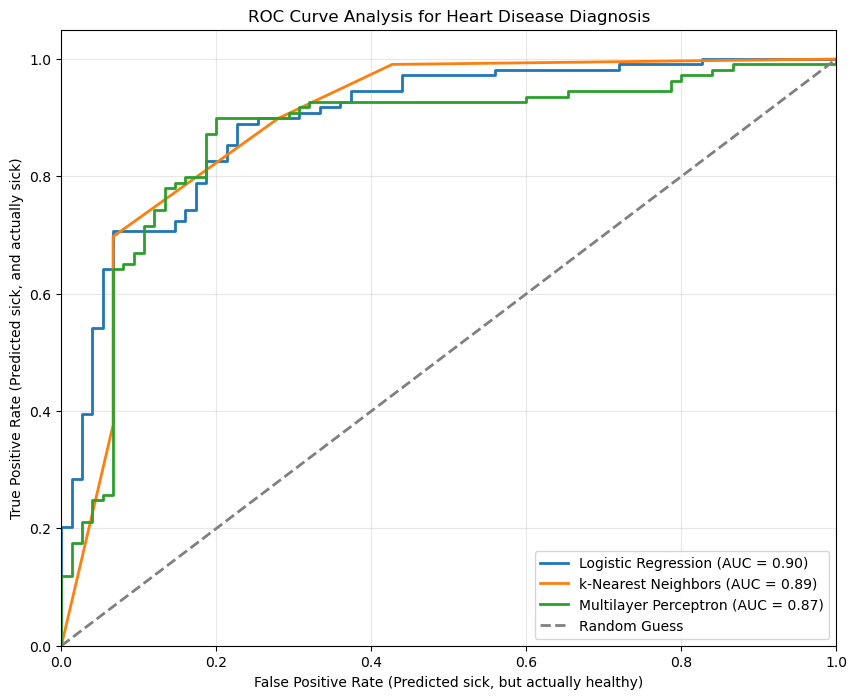

Note: An AUC (Area Under Curve) closer to 1.0 means a perfectly accurate diagnostic model!


In [3]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for each model
for name, model in models.items():
    # Get the probability of the prediction, not just the 0 or 1
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Plot the line
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the "random guess" baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicted sick, but actually healthy)')
plt.ylabel('True Positive Rate (Predicted sick, and actually sick)')
plt.title('ROC Curve Analysis for Heart Disease Diagnosis')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("Note: An AUC (Area Under Curve) closer to 1.0 means a perfectly accurate diagnostic model!")

## Clinical Insights (Feature Importance)

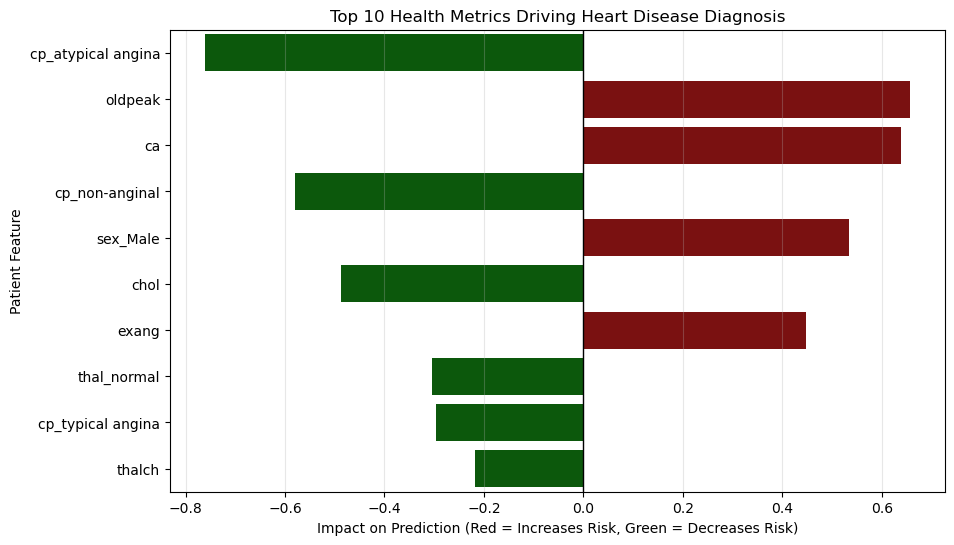

Interpretation:
- Red bars pushing RIGHT: Higher values in these metrics increase the AI's prediction of Heart Disease.
- Green bars pushing LEFT: Higher values in these metrics lower the AI's prediction of Heart Disease.


In [6]:
# Extract the coefficients (weights) from the trained Logistic Regression model
log_reg_model = models["Logistic Regression"]
importances = log_reg_model.coef_[0]

# Create a DataFrame to make it look nice
feature_df = pd.DataFrame({
    'Health Metric': X.columns,
    'Importance': importances
})

# Sort by absolute magnitude (most impactful features at the top)
feature_df['Absolute_Importance'] = feature_df['Importance'].abs()
feature_df = feature_df.sort_values(by='Absolute_Importance', ascending=False)

# Get the top 10 features
top_10_features = feature_df.head(10)

# FIX: Convert the color conditions into a plain Python list so Seaborn doesn't crash
color_list = top_10_features['Importance'].apply(lambda x: 'darkred' if x > 0 else 'darkgreen').tolist()

# Visualize the Top 10 most important health metrics
plt.figure(figsize=(10, 6))

# FIX: Added 'hue', 'legend=False', and passed the plain list to 'palette'
sns.barplot(
    data=top_10_features, 
    x='Importance', 
    y='Health Metric', 
    hue='Health Metric',
    palette=color_list,
    legend=False
)

plt.title('Top 10 Health Metrics Driving Heart Disease Diagnosis')
plt.xlabel('Impact on Prediction (Red = Increases Risk, Green = Decreases Risk)')
plt.ylabel('Patient Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Interpretation:")
print("- Red bars pushing RIGHT: Higher values in these metrics increase the AI's prediction of Heart Disease.")
print("- Green bars pushing LEFT: Higher values in these metrics lower the AI's prediction of Heart Disease.")